In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

In [2]:
# Constants / Configs
POSITION_MASTER = {1: 'GKP', 2: 'DEF', 3: 'MID', 4: 'FWD'}
PLAYERS_NUMERIC_COLUMNS = ['form', 'points_per_game', 'ep_next', 'influence', 'creativity', 'threat', 'ict_index', 
                           'value_form', 'value_season', 'selected_by_percent', 'expected_goals', 'expected_assists', 
                           'expected_goal_involvements', 'expected_goals_conceded', 'clean_sheets_per_90', 'saves_per_90']
PLAYERS_NORMALIZATION_COLUMNS = ['points_per_game', 'ep_next', 'fdr', 'ict_index', 'chance_of_playing_next_round', 
                                 'clean_sheets_per_90', 'saves_per_90', 'threat']

GKP_WEIGHTS = {
    'points_per_game': 0.20,
    'ep_next': 0.15,
    'fdr': 0.15,
    'chance_of_playing_next_round': 0.10,
    'clean_sheets_per_90': 0.275,
    'saves_per_90': 0.125,
}

DEF_WEIGHTS = {
    'points_per_game': 0.20,
    'ep_next': 0.20,
    'fdr': 0.15,
    'chance_of_playing_next_round': 0.05,
    'ict_index': 0.25,
    'clean_sheets_per_90': 0.15,
}

MID_WEIGHTS = {
    'points_per_game': 0.20,
    'ep_next': 0.20,
    'fdr': 0.18,
    'chance_of_playing_next_round': 0.10,
    'ict_index': 0.32,
}

FWD_WEIGHTS = {
    'points_per_game': 0.20,
    'ep_next': 0.225,
    'fdr': 0.1,
    'chance_of_playing_next_round': 0.10,
    'threat': 0.375,  # pick threat over expected_goals — forward-looking
}

In [3]:
# Get Next Gameweek
bootstrap_response = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/')
bootstrap_response.raise_for_status()
bootstrap_data = bootstrap_response.json()
events = bootstrap_data["events"]

next_gw_title: str | None = None
next_gw_id: int | None = None

for event in events:
  if event["is_next"]:
    next_gw_id = event["id"]
    next_gw_title = event["name"]
    break

# The upcoming GW we are predicting for
# Sheet was fetched before this GW was played
GAMEWEEK = f'GW{next_gw_id}'

In [4]:
# Load Data.
players_df = pd.read_excel('./data/players_master.xlsx', sheet_name=GAMEWEEK)
teams_df = pd.read_excel('./data/teams_master.xlsx', sheet_name=GAMEWEEK)
fixtures_df = pd.read_excel('./data/fixtures_master.xlsx', sheet_name=GAMEWEEK)

In [5]:
# Computations

players_df['full_name'] = players_df['first_name'] + ' ' + players_df['second_name']
players_df['position'] = players_df['element_type'].map(POSITION_MASTER)
players_df['team_name'] = players_df['team'].map(dict(zip(teams_df['id'], teams_df['name'])))

# Using `errors='coerce'` to enter NaN for invalid values without raising exceptions.
for col in PLAYERS_NUMERIC_COLUMNS:
  players_df[col] = pd.to_numeric(players_df[col], errors='coerce')

# FPL passes values into 'chance_of_playing_next_round' only during issues example 50, 75.
# So missing value means player is fit to play. So replacing NA with 100 for calculations.
players_df['chance_of_playing_next_round'] = players_df['chance_of_playing_next_round'].fillna(100)
players_df['ep_next'] = players_df['ep_next'].fillna(0)
players_df = players_df[players_df['status'].isin(['a', 'i', 'd'])]

# Filtering out players with less than 900 minutes played.
players_df = players_df[players_df['minutes'] > 900]

# FPL sends cost (euro) multiplied for 10 by default.
players_df['cost'] = players_df['now_cost'] / 10
players_df['points_per_euro'] = players_df['total_points'] / players_df['cost']

home = fixtures_df[['team_h', 'team_h_difficulty']].rename(columns={'team_h': 'team_id', 'team_h_difficulty': 'fdr'})
away = fixtures_df[['team_a', 'team_a_difficulty']].rename(columns={'team_a': 'team_id', 'team_a_difficulty': 'fdr'})
fdr_df = pd.concat([home, away])
players_df['fdr'] = players_df['team'].map(dict(zip(fdr_df['team_id'], fdr_df['fdr'])))


# Creating a fresh contiguous copy of the DataFrame in memory as pandas internally fragments memory.
players_df = players_df.copy()

for col in PLAYERS_NORMALIZATION_COLUMNS:
  # FDR (Difficulty) Low = Easy (Good), High = Difficult (Bad)
  # Saver Per 90: Bad team's GK would have to go through more shots, inturn save more, but also creates possibility of conceiding more.
  # Inverting normalization for these as we want HIGH = Good, LOW = Bad.
  if col in ['fdr', 'saves_per_90' ]:
    players_df[f'{col}_norm'] = 1 - ((players_df[col] - players_df[col].min()) / (players_df[col].max() - players_df[col].min()))
  else:
    players_df[f'{col}_norm'] = (players_df[col] - players_df[col].min()) / (players_df[col].max() - players_df[col].min())

In [6]:
# Scoring 

mask = players_df['position'] == 'GKP'
players_df.loc[mask, 'next_gw_score'] = sum([players_df.loc[mask, f'{col}_norm'] * value for col, value in GKP_WEIGHTS.items()])
mask = players_df['position'] == 'DEF'
players_df.loc[mask, 'next_gw_score'] = sum([players_df.loc[mask, f'{col}_norm'] * value for col, value in DEF_WEIGHTS.items()])
mask = players_df['position'] == 'MID'
players_df.loc[mask, 'next_gw_score'] = sum([players_df.loc[mask, f'{col}_norm'] * value for col, value in MID_WEIGHTS.items()])
mask = players_df['position'] == 'FWD'
players_df.loc[mask, 'next_gw_score'] = sum([players_df.loc[mask, f'{col}_norm'] * value for col, value in FWD_WEIGHTS.items()])

# Players who actually play. (Score points)
active_players = players_df[players_df['total_points'] > 0]

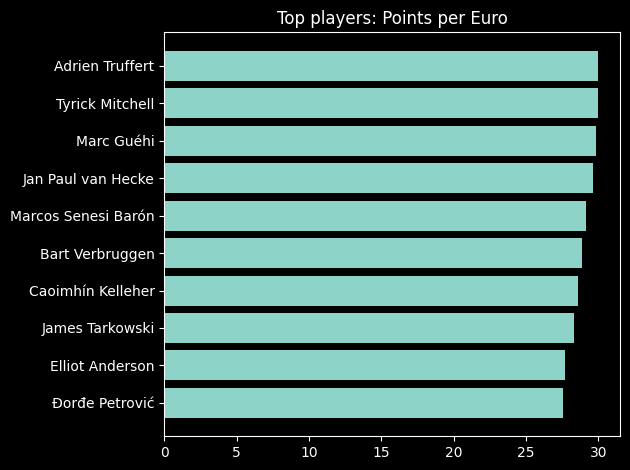

In [7]:
# Visualizations
plt.style.use('dark_background')

fig, ax = plt.subplots()
top_10_by_value = players_df.sort_values(by='points_per_euro', ascending=False).head(10).sort_values(by='points_per_euro', ascending=True)
ax.barh(top_10_by_value['full_name'], top_10_by_value['points_per_euro'])
ax.set_title('Top players: Points per Euro')
plt.tight_layout()
plt.show()

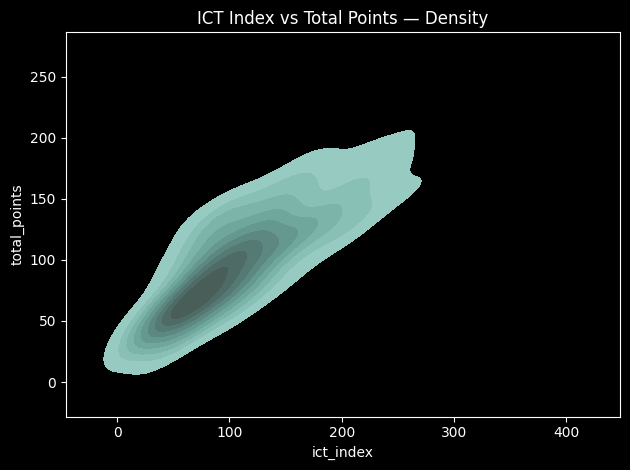

In [8]:
fig, ax = plt.subplots()
sns.kdeplot(data=active_players, x='ict_index', y='total_points', fill=True, ax=ax)
ax.set_title('ICT Index vs Total Points — Density')
plt.tight_layout()
plt.show()

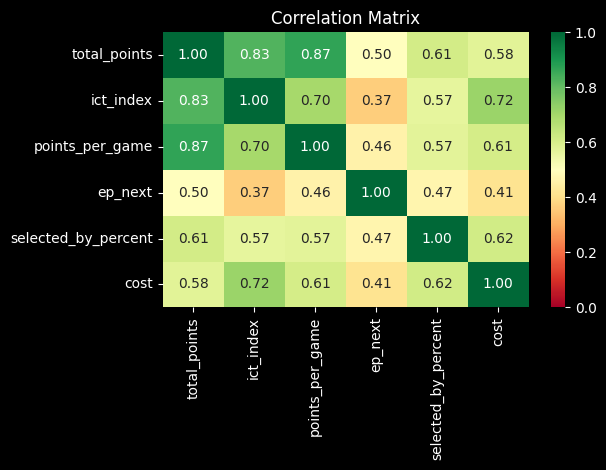

In [9]:
corr_cols = ['total_points', 'ict_index', 'points_per_game', 'ep_next', 'selected_by_percent', 'cost']
corr_matrix = players_df[corr_cols].corr()

fig, ax = plt.subplots()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', ax=ax, vmin=0, vmax=1, cmap='RdYlGn')
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

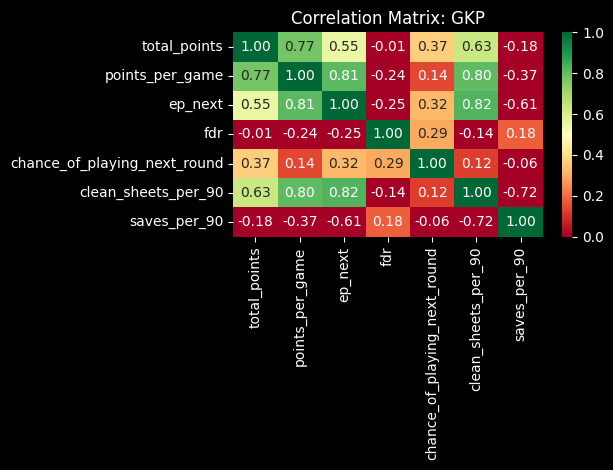

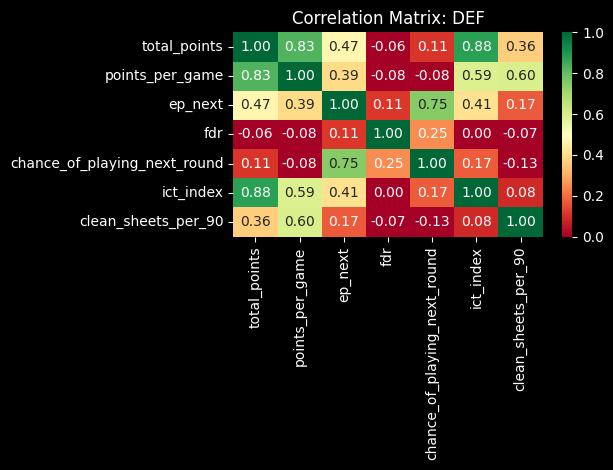

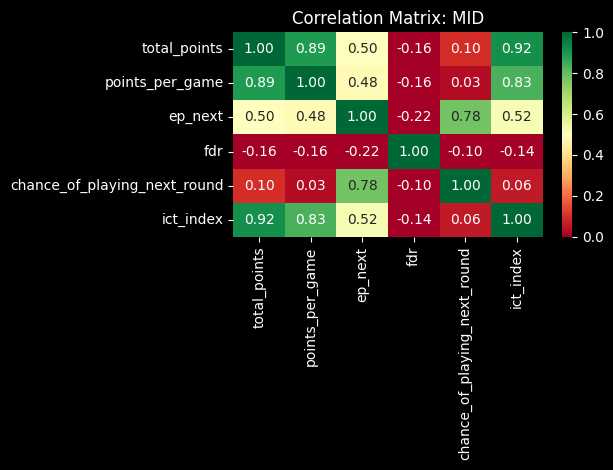

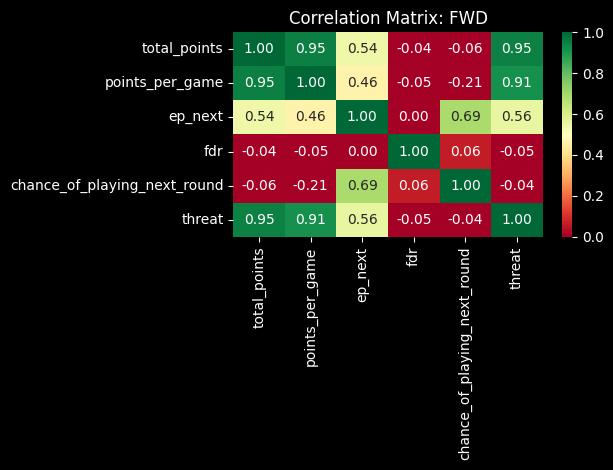

In [10]:
corr_cols = ['total_points'] +  [col for col, _ in GKP_WEIGHTS.items()]
temp_df =  players_df[players_df['position'] == 'GKP']
corr_matrix = temp_df[corr_cols].corr()

fig, ax = plt.subplots()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', ax=ax, vmin=0, vmax=1, cmap='RdYlGn')
ax.set_title('Correlation Matrix: GKP')
plt.tight_layout()
plt.show()

corr_cols = ['total_points'] +  [col for col, _ in DEF_WEIGHTS.items()]
temp_df =  players_df[players_df['position'] == 'DEF']
corr_matrix = temp_df[corr_cols].corr()

fig, ax = plt.subplots()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', ax=ax, vmin=0, vmax=1, cmap='RdYlGn')
ax.set_title('Correlation Matrix: DEF')
plt.tight_layout()
plt.show()

corr_cols = ['total_points'] +  [col for col, _ in MID_WEIGHTS.items()]
temp_df =  players_df[players_df['position'] == 'MID']
corr_matrix = temp_df[corr_cols].corr()

fig, ax = plt.subplots()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', ax=ax, vmin=0, vmax=1, cmap='RdYlGn')
ax.set_title('Correlation Matrix: MID')
plt.tight_layout()
plt.show()

corr_cols = ['total_points'] +  [col for col, _ in FWD_WEIGHTS.items()]
temp_df =  players_df[players_df['position'] == 'FWD']
corr_matrix = temp_df[corr_cols].corr()

fig, ax = plt.subplots()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', ax=ax, vmin=0, vmax=1, cmap='RdYlGn')
ax.set_title('Correlation Matrix: FWD')
plt.tight_layout()
plt.show()

In [11]:
rec_cols = ['full_name', 'team_name', 'position', 'fdr', 'cost', 'total_points', 'points_per_euro', 'next_gw_score']
recommendations = players_df.sort_values(by=['position', 'next_gw_score'], ascending=False).groupby('position').head(10)[rec_cols]

for _, pos in POSITION_MASTER.items():
  temp_df = recommendations[recommendations['position'] == pos]
  display(
    temp_df.sort_values(by='next_gw_score', ascending=False)
    .style
    .set_caption(pos)
    .background_gradient(subset=['next_gw_score'], cmap='Greens')
    .format({'next_gw_score': '{:.2f}', 'cost': '£{:.1f}'})
  )

,full_name,team_name,position,fdr,cost,total_points,points_per_euro,next_gw_score
0,David Raya Martín,Arsenal,GKP,2,£6.0,162,27.000000,0.79
392,Gianluigi Donnarumma,Man City,GKP,3,£5.5,135,24.545455,0.65
357,Alisson Becker,Liverpool,GKP,3,£5.5,91,16.545455,0.59
543,Robin Roefs,Sunderland,GKP,2,£5.0,136,27.200000,0.58
424,Senne Lammens,Man Utd,GKP,2,£5.0,109,21.800000,0.57
231,Jordan Pickford,Everton,GKP,3,£5.5,135,24.545455,0.57
480,Matz Sels,Nott'm Forest,GKP,2,£5.0,105,21.000000,0.54
203,Dean Henderson,Crystal Palace,GKP,3,£5.0,131,26.200000,0.53
82,Caoimhín Kelleher,Brentford,GKP,3,£5.0,143,28.600000,0.53
141,Robert Lynch Sánchez,Chelsea,GKP,3,£5.0,113,22.600000,0.51


,full_name,team_name,position,fdr,cost,total_points,points_per_euro,next_gw_score
3,Gabriel dos Santos Magalhães,Arsenal,DEF,2,£8.0,209,26.125000,0.79
395,Nico O'Reilly,Man City,DEF,3,£6.5,160,24.615385,0.64
7,Riccardo Calafiori,Arsenal,DEF,2,£5.5,109,19.818182,0.63
396,Marc Guéhi,Man City,DEF,3,£6.0,179,29.833333,0.62
363,Virgil van Dijk,Liverpool,DEF,3,£6.5,175,26.923077,0.60
547,Nordi Mukiele,Sunderland,DEF,2,£5.5,151,27.454545,0.59
513,Marcos Senesi Barón,Spurs,DEF,3,£6.0,175,29.166667,0.59
234,James Tarkowski,Everton,DEF,3,£6.0,170,28.333333,0.58
397,Matheus Nunes,Man City,DEF,3,£6.0,154,25.666667,0.58
205,Daniel Muñoz Mejía,Crystal Palace,DEF,3,£5.5,136,24.727273,0.57


,full_name,team_name,position,fdr,cost,total_points,points_per_euro,next_gw_score
438,Bruno Borges Fernandes,Man Utd,MID,2,£12.0,235,19.583333,1.00
11,Bukayo Saka,Arsenal,MID,2,£9.5,157,16.526316,0.77
493,Morgan Gibbs-White,Nott'm Forest,MID,2,£8.0,188,23.500000,0.76
405,Antoine Semenyo,Man City,MID,3,£8.5,202,23.764706,0.73
439,Bryan Mbeumo,Man Utd,MID,2,£8.0,148,18.500000,0.73
12,Declan Rice,Arsenal,MID,2,£7.5,184,24.533333,0.73
440,Matheus Santos Carneiro da Cunha,Man Utd,MID,2,£8.0,143,17.875000,0.70
156,Enzo Fernández,Chelsea,MID,3,£7.0,157,22.428571,0.68
375,Dominik Szoboszlai,Liverpool,MID,3,£7.0,160,22.857143,0.68
138,Morgan Rogers,Chelsea,MID,3,£7.5,169,22.533333,0.66


,full_name,team_name,position,fdr,cost,total_points,points_per_euro,next_gw_score
419,Erling Haaland,Man City,FWD,3,£15.5,239,15.419355,0.97
104,Igor Thiago Nascimento Rodrigues,Brentford,FWD,3,£8.0,181,22.625000,0.73
53,Ollie Watkins,Aston Villa,FWD,3,£8.0,167,20.875000,0.73
164,João Pedro Junqueira de Jesus,Chelsea,FWD,3,£7.5,177,23.600000,0.66
353,Dominic Calvert-Lewin,Leeds,FWD,3,£6.0,142,23.666667,0.64
24,Viktor Gyökeres,Arsenal,FWD,2,£7.5,128,17.066667,0.61
541,Richarlison de Andrade,Spurs,FWD,3,£6.0,119,19.833333,0.58
227,Jean-Philippe Mateta,Crystal Palace,FWD,3,£6.5,114,17.538462,0.57
503,Igor Jesus Maciel da Cruz,Nott'm Forest,FWD,2,£6.0,114,19.000000,0.57
451,Benjamin Sesko,Man Utd,FWD,2,£7.0,111,15.857143,0.56
